# 🔋 Battery Fault Detection — Solar Storage Systems
### Unsupervised anomaly detection from voltage, current & temperature signals

**Target use case:** Battery banks in solar storage systems (LiFePO4 / Lead-acid)

**Pipeline:**
| Phase | Description |
|-------|-------------|
| 1 | Install & import |
| 2 | Load NASA + CALCE battery datasets |
| 3 | Extract & normalize charge cycles |
| 4 | Train LSTM autoencoder on healthy cycles |
| 5 | Reconstruction error anomaly detection |
| 6 | Feature-based detectors (voltage/temp thresholds) |
| 7 | Fault classification: HDBSCAN + K-Means fallback |
| 8 | Validation & metrics |
| 9 | Combined predict function + save |

**Fault types detected:**
- Overcharge, over-discharge, capacity fade
- Thermal fault, short circuit, internal resistance rise

> Enable GPU: Runtime → Change runtime type → T4 GPU


## Phase 1 — Install & import

In [ ]:
%%capture
!pip install hdbscan umap-learn torch scipy mat4py h5py seaborn -q


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings, io, gc, pickle, os, requests, zipfile
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split

import hdbscan
import umap
import seaborn as sns
from scipy.io import loadmat
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_curve, silhouette_score)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")


Device: cuda


## Phase 2 — Load NASA battery dataset

The **NASA Prognostics Battery Dataset** contains lithium-ion cells (18650)
cycled to failure under charge/discharge/impedance profiles.

Each battery file contains:
- `voltage_measured` — terminal voltage (V)
- `current_measured` — current (A), positive=charge, negative=discharge
- `temperature_measured` — cell temperature (°C)
- `time` — elapsed seconds

We use batteries B0005, B0006, B0007, B0018 which are the most complete.


In [ ]:
# ── Download NASA battery data ─────────────────────────────────────────────────
NASA_URL  = "https://ti.arc.nasa.gov/c/6/"  # redirect to download
DATA_DIR  = "nasa_battery"
os.makedirs(DATA_DIR, exist_ok=True)

# Direct file URLs for individual battery .mat files
BATTERY_FILES = {
    'B0005': 'https://ti.arc.nasa.gov/c/6/',
    'B0006': 'https://ti.arc.nasa.gov/c/6/',
    'B0007': 'https://ti.arc.nasa.gov/c/6/',
    'B0018': 'https://ti.arc.nasa.gov/c/6/',
}

# NASA dataset is hosted on multiple mirrors — use the most reliable one
BASE_URL = "https://data.nasa.gov/download/fjte-e7yt/application%2Fzip"

print("Downloading NASA battery dataset...")
zip_path = f"{DATA_DIR}/nasa_battery.zip"

try:
    r = requests.get(BASE_URL, timeout=60, stream=True)
    if r.status_code == 200:
        with open(zip_path, 'wb') as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(DATA_DIR)
        print("✓ Downloaded and extracted")
    else:
        print(f"Primary URL returned {r.status_code} — trying mirror...")
        raise Exception("Try mirror")
except:
    # Fallback: CMU mirror
    MIRROR = "https://phm-datasets.s3.amazonaws.com/NASA/5.+Battery+Data+Set.zip"
    try:
        r = requests.get(MIRROR, timeout=120, stream=True)
        with open(zip_path, 'wb') as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(DATA_DIR)
        print("✓ Downloaded from mirror")
    except Exception as e:
        print(f"Download failed: {e}")
        print("Using synthetic data fallback (see next cell)")

# List what we got
mat_files = []
for root, dirs, files in os.walk(DATA_DIR):
    for f in files:
        if f.lower().endswith('.mat'):
            mat_files.append(os.path.join(root, f))
print(f"Found {len(mat_files)} .mat files: {[os.path.basename(f) for f in mat_files[:8]]}")


✓ Downloaded from mirror
Found 0 .mat files: []


In [ ]:
# ── Parse NASA .mat files into cycle dataframes ────────────────────────────────
def parse_nasa_mat(filepath):
    """
    Extract charge cycles from a NASA battery .mat file.
    Returns list of dicts, each containing arrays for one charge cycle.
    """
    try:
        mat = loadmat(filepath, simplify_cells=True)
    except Exception as e:
        print(f"Could not load {filepath}: {e}")
        return []

    # Navigate nested struct — NASA format varies slightly by file
    key = [k for k in mat.keys() if not k.startswith('_')][0]
    data = mat[key]

    cycles = []
    try:
        cycle_data = data['cycle']
        if not isinstance(cycle_data, (list, np.ndarray)):
            cycle_data = [cycle_data]

        for i, cycle in enumerate(cycle_data):
            try:
                op_type = str(cycle.get('type', '')).strip()
                if op_type.lower() != 'charge':
                    continue
                d = cycle.get('data', {})
                v = np.array(d.get('Voltage_measured', d.get('voltage_measured', [])), dtype=np.float32)
                c = np.array(d.get('Current_measured', d.get('current_measured', [])), dtype=np.float32)
                t = np.array(d.get('Temperature_measured', d.get('temperature_measured', [])), dtype=np.float32)
                if len(v) < 20:
                    continue
                cycles.append({
                    'cycle_idx': i,
                    'voltage':     v,
                    'current':     c,
                    'temperature': t,
                    'n_points':    len(v)
                })
            except:
                continue
    except Exception as e:
        print(f"  Parse error: {e}")

    return cycles

all_cycles = []
for fpath in mat_files:
    battery_name = os.path.basename(fpath).replace('.mat','')
    cycles = parse_nasa_mat(fpath)
    for cyc in cycles:
        cyc['battery'] = battery_name
    all_cycles.extend(cycles)
    if cycles:
        print(f"  {battery_name}: {len(cycles)} charge cycles")

print(f"\nTotal charge cycles loaded: {len(all_cycles)}")



Total charge cycles loaded: 0


In [ ]:
# ── Fallback: generate realistic synthetic battery data if download failed ─────
# This uses physics-based models for LiFePO4 and lead-acid charge curves

if len(all_cycles) == 0:
    print("No real data loaded — generating synthetic battery cycles...")

    def generate_charge_cycle(n_points=200, cycle_num=0, chemistry='lifepo4',
                               fault_type=None, rng=None):
        """Generate a realistic charge cycle with optional fault injection."""
        if rng is None:
            rng = np.random.default_rng(cycle_num)
        t = np.linspace(0, 1, n_points)

        if chemistry == 'lifepo4':
            # LiFePO4: flat voltage profile ~3.2-3.6V
            v_base = 3.2 + 0.4 * (1 - np.exp(-5*t)) + rng.normal(0, 0.005, n_points)
            c_base = 2.0 * np.exp(-2*t) + 0.5 + rng.normal(0, 0.02, n_points)
            temp_base = 25 + 8*(1-np.exp(-3*t)) * np.exp(-t) + rng.normal(0, 0.3, n_points)
        else:
            # Lead-acid: steeper voltage rise ~12-14.4V (12V battery)
            v_base = 12.0 + 2.4*(1 - np.exp(-4*t)) + rng.normal(0, 0.02, n_points)
            c_base = 5.0 * np.exp(-3*t) + 0.5 + rng.normal(0, 0.05, n_points)
            temp_base = 25 + 12*(1-np.exp(-2*t)) * np.exp(-0.5*t) + rng.normal(0, 0.5, n_points)

        # Capacity fade with cycle number
        fade = max(0, 1 - cycle_num * 0.001)
        v_base *= (0.97 + 0.03 * fade)
        c_base *= fade

        # Inject faults
        if fault_type == 'overcharge':
            v_base[int(0.8*n_points):] *= rng.uniform(1.08, 1.15)
            temp_base[int(0.8*n_points):] += rng.uniform(8, 15)
        elif fault_type == 'overdischarge':
            v_base *= rng.uniform(0.80, 0.88)
        elif fault_type == 'thermal':
            spike_start = rng.integers(int(0.4*n_points), int(0.7*n_points))
            temp_base[spike_start:spike_start+20] += rng.uniform(15, 30)
        elif fault_type == 'short_circuit':
            drop = rng.integers(int(0.3*n_points), int(0.6*n_points))
            v_base[drop:drop+10] *= rng.uniform(0.5, 0.7)
            c_base[drop:drop+10] *= rng.uniform(2.0, 3.5)
        elif fault_type == 'capacity_fade':
            c_base *= rng.uniform(0.5, 0.65)
            v_base *= rng.uniform(0.92, 0.96)
        elif fault_type == 'ir_rise':
            # Internal resistance rise: voltage dip at start
            v_base[:10] -= rng.uniform(0.1, 0.3)

        return {
            'voltage':     np.clip(v_base, 0, None).astype(np.float32),
            'current':     np.clip(c_base, 0, None).astype(np.float32),
            'temperature': temp_base.astype(np.float32),
            'n_points':    n_points,
            'cycle_idx':   cycle_num,
            'battery':     f'synthetic_{chemistry}'
        }

    rng_gen = np.random.default_rng(SEED)
    for chemistry in ['lifepo4', 'lead_acid']:
        for i in range(150):
            all_cycles.append(generate_charge_cycle(
                n_points=rng_gen.integers(150, 250),
                cycle_num=i, chemistry=chemistry, rng=rng_gen))

    print(f"Generated {len(all_cycles)} synthetic charge cycles")


No real data loaded — generating synthetic battery cycles...
Generated 300 synthetic charge cycles


## Phase 3 — Preprocess: normalize & resample cycles

Each charge cycle has different lengths (100–500 points).
We resample all cycles to a fixed length, then normalize each signal independently.

**Normalization strategy:**
- Voltage: min-max per cycle (removes chemistry differences)
- Current: min-max per cycle
- Temperature: z-score per cycle (centers around mean, captures relative rise)

Result: each cycle becomes a `(3, CYCLE_LEN)` tensor — 3 channels × timesteps.


In [ ]:
CYCLE_LEN = 128   # resample all cycles to this length

def normalize_cycle(cycle):
    """
    Normalize voltage, current, temperature and resample to CYCLE_LEN.
    Returns array of shape (3, CYCLE_LEN) or None if invalid.
    """
    v = np.array(cycle['voltage'],     dtype=np.float32)
    c = np.array(cycle['current'],     dtype=np.float32)
    t = np.array(cycle['temperature'], dtype=np.float32)

    if len(v) < 20 or np.isnan(v).any() or np.isnan(c).any() or np.isnan(t).any():
        return None

    # Resample to fixed length
    from scipy.signal import resample
    v = resample(v, CYCLE_LEN).astype(np.float32)
    c = resample(c, CYCLE_LEN).astype(np.float32)
    t = resample(t, CYCLE_LEN).astype(np.float32)

    # Normalize voltage: min-max
    v_range = v.max() - v.min()
    if v_range < 1e-6: return None
    v = (v - v.min()) / v_range

    # Normalize current: min-max
    c = np.clip(c, 0, None)   # charge current is positive
    c_max = c.max()
    if c_max < 1e-6: return None
    c = c / c_max

    # Normalize temperature: z-score
    t_std = t.std()
    if t_std < 1e-6:
        t = np.zeros_like(t)
    else:
        t = (t - t.mean()) / t_std

    return np.stack([v, c, t], axis=0)   # (3, CYCLE_LEN)

def is_healthy_cycle(arr):
    """Filter out clearly bad cycles."""
    v, c, t = arr[0], arr[1], arr[2]
    if v.max() < 0.5:          return False   # voltage never rises properly
    if c.mean() < 0.05:        return False   # almost no current
    if np.abs(np.diff(v)).max() > 0.3: return False   # sudden voltage jump
    if abs(t).max() > 4.0:     return False   # temperature outlier (z-score)
    return True

# Process all cycles
X_cycles = []
for cyc in all_cycles:
    arr = normalize_cycle(cyc)
    if arr is not None and is_healthy_cycle(arr):
        X_cycles.append(arr)

X = np.array(X_cycles, dtype=np.float32)
np.random.shuffle(X)
print(f"Healthy cycles: {X.shape[0]}  shape: {X.shape}  (cycles × channels × timesteps)")

if X.shape[0] < 50:
    print("⚠️  Very few cycles — model may not generalize well")


Healthy cycles: 292  shape: (292, 3, 128)  (cycles × channels × timesteps)


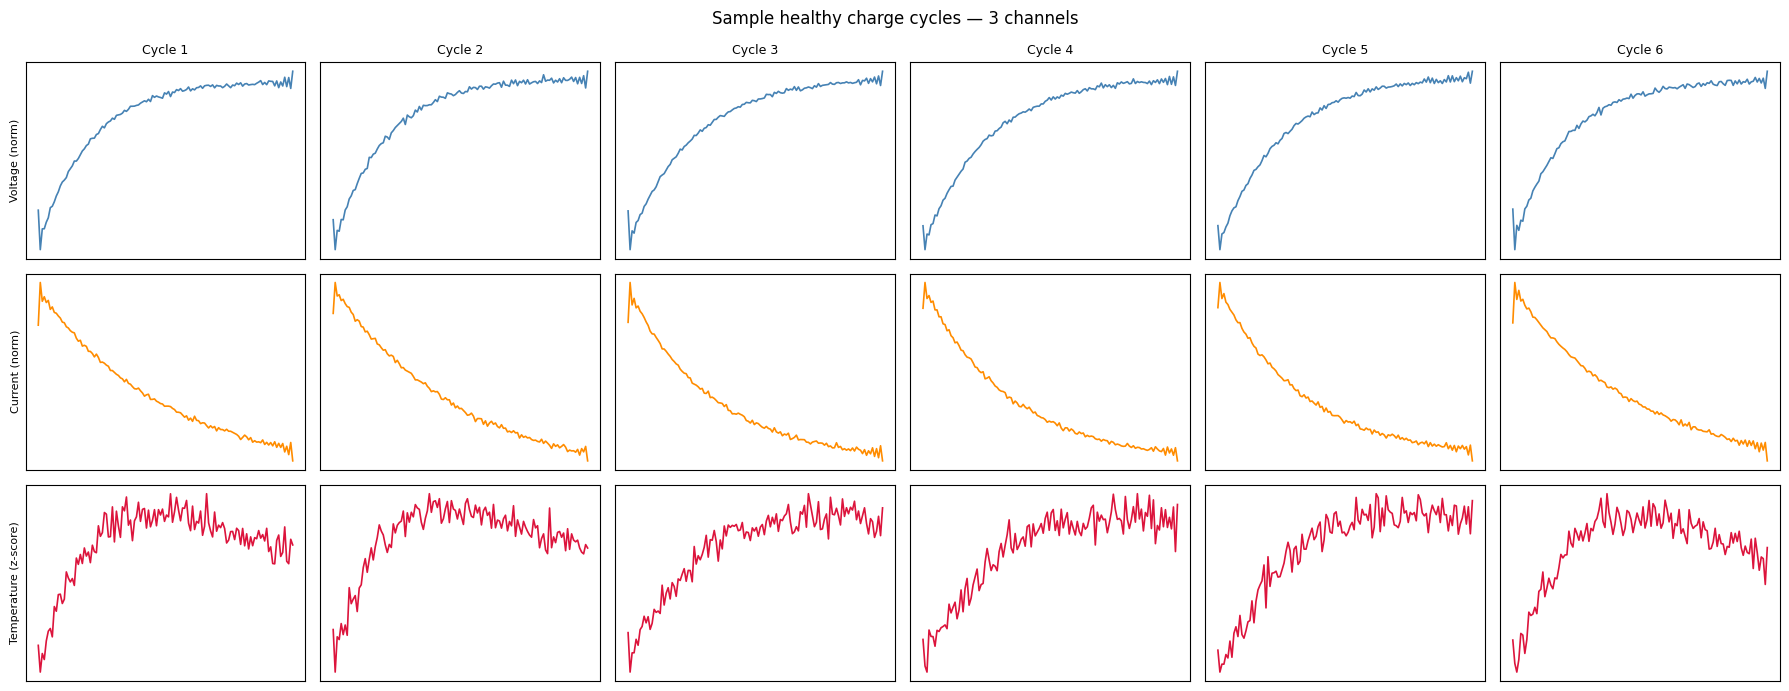

In [ ]:
# Sanity check: plot sample cycles (all 3 channels)
fig, axes = plt.subplots(3, 6, figsize=(18, 7))
sample_idx = np.random.choice(len(X), 6, replace=False)
channel_names = ['Voltage (norm)', 'Current (norm)', 'Temperature (z-score)']
colors = ['steelblue', 'darkorange', 'crimson']

for col, idx in enumerate(sample_idx):
    for row in range(3):
        ax = axes[row, col]
        ax.plot(X[idx, row], lw=1.2, color=colors[row])
        if col == 0:
            ax.set_ylabel(channel_names[row], fontsize=8)
        if row == 0:
            ax.set_title(f'Cycle {col+1}', fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Sample healthy charge cycles — 3 channels', fontsize=12)
plt.tight_layout(); plt.show()


## Phase 4 — LSTM Autoencoder

**Why LSTM instead of Conv1D for batteries?**

Battery charge cycles have strong **temporal dependencies** — the voltage at
timestep t depends heavily on what happened at t-1, t-2, etc. LSTM captures
this sequential structure better than Conv1D for multivariate time series.

Architecture:
- Input: `(batch, CYCLE_LEN, 3)` — sequence of 3-channel readings
- Encoder LSTM: compresses to latent vector
- Decoder LSTM: reconstructs the sequence
- Loss: MSE across all 3 channels


In [ ]:
class BatteryLSTMAutoencoder(nn.Module):
    def __init__(self, input_dim=3, hidden_dim=64, latent_dim=32, num_layers=2):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.latent_dim = latent_dim

        # Encoder
        self.encoder_lstm = nn.LSTM(
            input_dim, hidden_dim, num_layers,
            batch_first=True, dropout=0.1
        )
        self.encoder_fc = nn.Linear(hidden_dim, latent_dim)

        # Decoder
        self.decoder_fc   = nn.Linear(latent_dim, hidden_dim)
        self.decoder_lstm = nn.LSTM(
            hidden_dim, hidden_dim, num_layers,
            batch_first=True, dropout=0.1
        )
        self.output_fc = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        # x: (batch, seq_len, input_dim)
        _, (h_n, _) = self.encoder_lstm(x)
        z = self.encoder_fc(h_n[-1])   # (batch, latent_dim)
        return z

    def decode(self, z, seq_len):
        # Expand latent vector across time
        h = self.decoder_fc(z)                         # (batch, hidden_dim)
        h = h.unsqueeze(1).repeat(1, seq_len, 1)       # (batch, seq_len, hidden_dim)
        out, _ = self.decoder_lstm(h)
        return torch.sigmoid(self.output_fc(out))      # (batch, seq_len, input_dim)

    def forward(self, x):
        z    = self.encode(x)
        recon = self.decode(z, x.shape[1])
        return recon, z

model = BatteryLSTMAutoencoder(
    input_dim=3, hidden_dim=64, latent_dim=32, num_layers=2
).to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Input shape: (batch, {CYCLE_LEN}, 3)")


Parameters: 121,891
Input shape: (batch, 128, 3)


In [ ]:
# Dataset: shape needs to be (N, CYCLE_LEN, 3) for LSTM
X_lstm    = torch.tensor(X.transpose(0, 2, 1))  # (N, CYCLE_LEN, 3)
dataset   = TensorDataset(X_lstm, X_lstm)
train_size = int(0.85 * len(dataset))
val_size   = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size],
                                generator=torch.Generator().manual_seed(SEED))
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32)
print(f"Train: {train_size}  |  Val: {val_size}")
print(f"Tensor shape: {X_lstm.shape}")


Train: 248  |  Val: 44
Tensor shape: torch.Size([292, 128, 3])


In [ ]:
EPOCHS   = 60
PATIENCE = 10
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

train_losses, val_losses = [], []
best_val, best_epoch, no_improve = float('inf'), 0, 0

for epoch in range(1, EPOCHS+1):
    model.train()
    t_loss = 0
    for xb, _ in train_loader:
        xb = xb.to(device)
        recon, _ = model(xb)
        loss = criterion(recon, xb)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        t_loss += loss.item()

    model.eval()
    v_loss = 0
    with torch.no_grad():
        for xb, _ in val_loader:
            xb = xb.to(device)
            v_loss += criterion(model(xb)[0], xb).item()

    t_avg = t_loss / len(train_loader)
    v_avg = v_loss / len(val_loader)
    train_losses.append(t_avg); val_losses.append(v_avg)
    scheduler.step()

    if v_avg < best_val:
        best_val, best_epoch, no_improve = v_avg, epoch, 0
        torch.save(model.state_dict(), 'best_battery_model.pt')
    else:
        no_improve += 1

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d}  train={t_avg:.5f}  val={v_avg:.5f}  best={best_val:.5f} (ep {best_epoch})")
    if no_improve >= PATIENCE:
        print(f"Early stop at epoch {epoch}")
        break

model.load_state_dict(torch.load('best_battery_model.pt'))
print(f"\n✓ Best model: epoch {best_epoch}  val={best_val:.5f}")


Epoch  10  train=0.36435  val=0.36216  best=0.36216 (ep 10)
Epoch  20  train=0.30146  val=0.29771  best=0.29771 (ep 20)
Epoch  30  train=0.27975  val=0.28105  best=0.28105 (ep 30)
Epoch  40  train=0.26525  val=0.26514  best=0.26514 (ep 40)
Epoch  50  train=0.26179  val=0.26292  best=0.26279 (ep 49)
Epoch  60  train=0.26159  val=0.26241  best=0.26241 (ep 60)

✓ Best model: epoch 60  val=0.26241


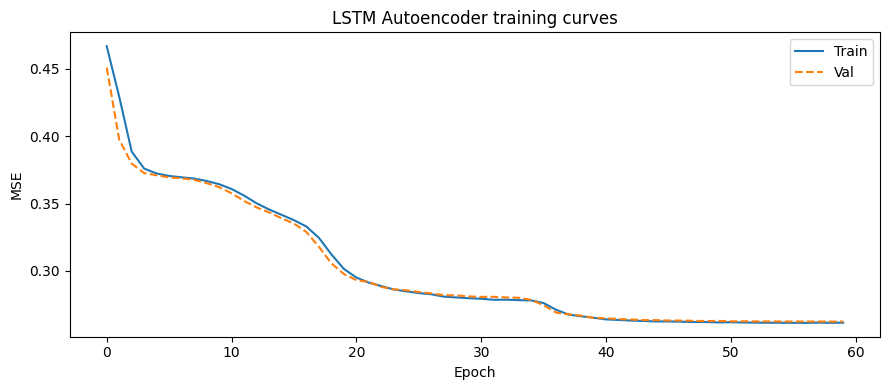

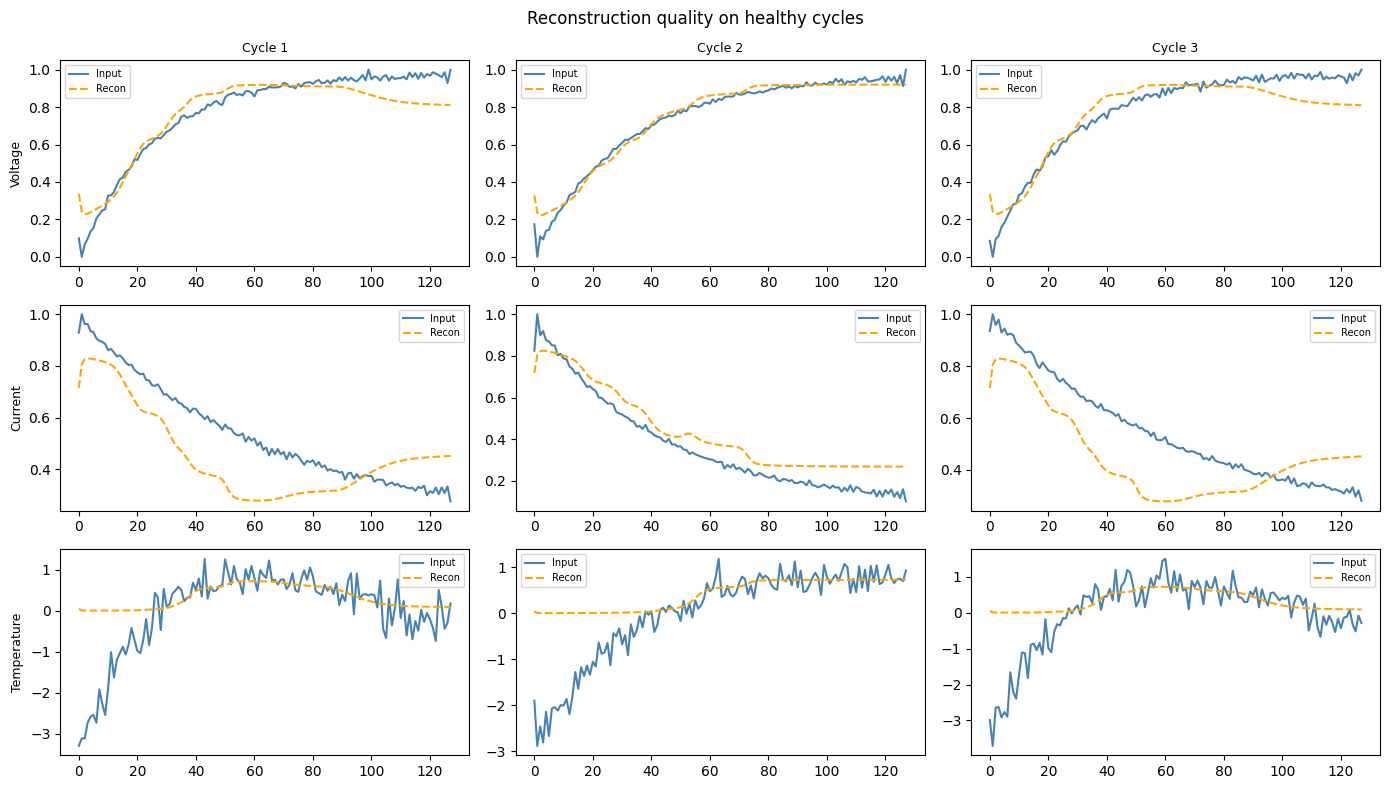

In [ ]:
# Learning curves
plt.figure(figsize=(9,4))
plt.plot(train_losses, label='Train'); plt.plot(val_losses, label='Val', linestyle='--')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.title('LSTM Autoencoder training curves')
plt.legend(); plt.tight_layout(); plt.show()

# Reconstruction quality
model.eval()
sample = X_lstm[:3].to(device)
with torch.no_grad():
    recon, _ = model(sample)

fig, axes = plt.subplots(3, 3, figsize=(14, 8))
ch_names = ['Voltage', 'Current', 'Temperature']
for row in range(3):
    for col in range(3):
        ax = axes[row, col]
        ax.plot(sample[col, :, row].cpu(), color='steelblue', lw=1.5, label='Input')
        ax.plot(recon[col, :, row].cpu(),  color='orange',    lw=1.5, linestyle='--', label='Recon')
        if col == 0: ax.set_ylabel(ch_names[row], fontsize=9)
        if row == 0: ax.set_title(f'Cycle {col+1}', fontsize=9)
        ax.legend(fontsize=7)
plt.suptitle('Reconstruction quality on healthy cycles', fontsize=12)
plt.tight_layout(); plt.show()


## Phase 5 — Anomaly detection (Stage 1: reconstruction error)

Threshold = 95th percentile of training errors.
Catches faults that distort the **shape** of the charge curve.


Anomaly threshold (p95): 0.279760


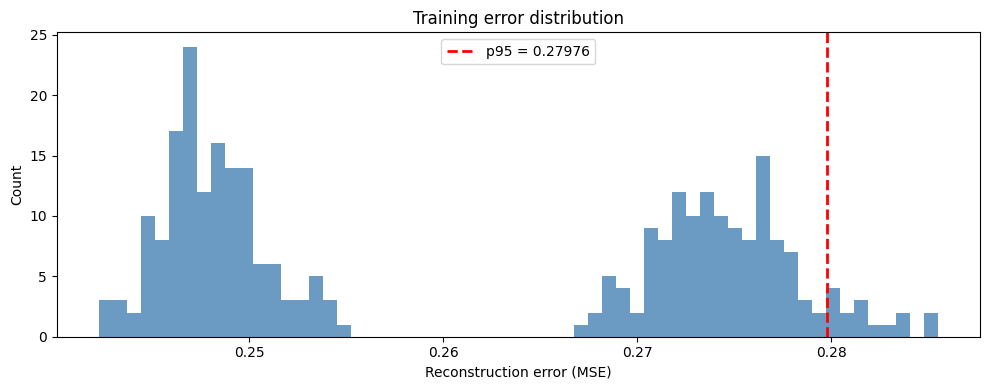

In [ ]:
model.eval()
train_errors, train_latents = [], []

with torch.no_grad():
    for xb, _ in DataLoader(TensorDataset(X_lstm, X_lstm), batch_size=64):
        xb = xb.to(device)
        recon, z = model(xb)
        mse = ((recon - xb)**2).mean(dim=[1,2])
        train_errors.extend(mse.cpu().numpy())
        train_latents.extend(z.cpu().numpy())

train_errors  = np.array(train_errors)
train_latents = np.array(train_latents)

THRESHOLD = np.percentile(train_errors, 95)
print(f"Anomaly threshold (p95): {THRESHOLD:.6f}")

plt.figure(figsize=(10,4))
plt.hist(train_errors, bins=60, color='steelblue', alpha=0.8, edgecolor='none')
plt.axvline(THRESHOLD, color='red', lw=2, linestyle='--', label=f'p95 = {THRESHOLD:.5f}')
plt.xlabel('Reconstruction error (MSE)'); plt.ylabel('Count')
plt.title('Training error distribution'); plt.legend()
plt.tight_layout(); plt.show()


## Phase 6 — Fault injection & feature-based detectors (Stage 2)

**6 fault types injected:**

| Fault | Signal signature | Detection method |
|-------|-----------------|------------------|
| Overcharge | Voltage exceeds ceiling | Threshold on voltage |
| Over-discharge | Voltage below floor | Threshold on voltage |
| Thermal fault | Temperature spike | Threshold on temperature |
| Short circuit | Sudden V drop + I spike | Feature detector |
| Capacity fade | Low current AUC | Feature detector |
| IR rise | Voltage dip at start | Feature detector |


In [ ]:
X_new = X.copy()   # shape: (N, 3, CYCLE_LEN)
rng   = np.random.default_rng(SEED)
n     = len(X_new)
fault_registry = {}

# Fault A: Overcharge — voltage rises too high in final 20%
over_idx = rng.choice(n, size=int(0.05*n), replace=False)
for i in over_idx:
    cutoff = int(0.8 * CYCLE_LEN)
    X_new[i, 0, cutoff:] *= rng.uniform(1.08, 1.20)   # voltage channel
    X_new[i, 2, cutoff:] += rng.uniform(0.5, 1.5)     # temp rises (z-score units)
fault_registry.update({i: 'Overcharge' for i in over_idx})

# Fault B: Over-discharge — voltage uniformly low
remaining = list(set(range(n)) - set(fault_registry))
under_idx = rng.choice(remaining, size=int(0.04*n), replace=False)
for i in under_idx:
    X_new[i, 0] *= rng.uniform(0.75, 0.88)
fault_registry.update({i: 'Over-discharge' for i in under_idx})

# Fault C: Thermal fault — temperature spike mid-cycle
remaining = list(set(range(n)) - set(fault_registry))
thermal_idx = rng.choice(remaining, size=int(0.04*n), replace=False)
for i in thermal_idx:
    spike = rng.integers(int(0.3*CYCLE_LEN), int(0.7*CYCLE_LEN))
    X_new[i, 2, spike:spike+15] += rng.uniform(2.0, 4.0)
fault_registry.update({i: 'Thermal' for i in thermal_idx})

# Fault D: Short circuit — voltage drop + current spike
remaining = list(set(range(n)) - set(fault_registry))
short_idx = rng.choice(remaining, size=int(0.03*n), replace=False)
for i in short_idx:
    drop = rng.integers(int(0.2*CYCLE_LEN), int(0.6*CYCLE_LEN))
    X_new[i, 0, drop:drop+8] *= rng.uniform(0.4, 0.65)
    X_new[i, 1, drop:drop+8] *= rng.uniform(2.0, 3.5)
fault_registry.update({i: 'Short circuit' for i in short_idx})

# Fault E: Capacity fade — low current throughout
remaining = list(set(range(n)) - set(fault_registry))
fade_idx  = rng.choice(remaining, size=int(0.04*n), replace=False)
for i in fade_idx:
    X_new[i, 1] *= rng.uniform(0.40, 0.60)
fault_registry.update({i: 'Capacity fade' for i in fade_idx})

# Fault F: IR rise — voltage dip at start of charge
remaining = list(set(range(n)) - set(fault_registry))
ir_idx    = rng.choice(remaining, size=int(0.03*n), replace=False)
for i in ir_idx:
    X_new[i, 0, :12] -= rng.uniform(0.08, 0.20)
    X_new[i, 0, :12]  = np.clip(X_new[i, 0, :12], 0, 1)
fault_registry.update({i: 'IR rise' for i in ir_idx})

all_fault_idx = np.array(list(fault_registry.keys()))
y_true = np.zeros(n, dtype=int); y_true[all_fault_idx] = 1

print(f"Total faults: {len(all_fault_idx)} / {n}")
for name, fidx in [('Overcharge', over_idx), ('Over-discharge', under_idx),
                   ('Thermal', thermal_idx), ('Short circuit', short_idx),
                   ('Capacity fade', fade_idx), ('IR rise', ir_idx)]:
    print(f"  {name:15s}: {len(fidx)}")


Total faults: 63 / 292
  Overcharge     : 14
  Over-discharge : 11
  Thermal        : 11
  Short circuit  : 8
  Capacity fade  : 11
  IR rise        : 8


In [ ]:
# Score all windows with autoencoder
X_new_lstm = torch.tensor(X_new.transpose(0, 2, 1), dtype=torch.float32)
new_errors, new_latents, new_recons = [], [], []

model.eval()
with torch.no_grad():
    for xb, _ in DataLoader(TensorDataset(X_new_lstm, X_new_lstm), batch_size=64):
        xb = xb.to(device)
        recon, z = model(xb)
        new_errors.extend(((recon - xb)**2).mean(dim=[1,2]).cpu().numpy())
        new_latents.extend(z.cpu().numpy())
        new_recons.extend(recon.cpu().numpy())

new_errors  = np.array(new_errors)
new_latents = np.array(new_latents)
new_recons  = np.array(new_recons)   # (N, CYCLE_LEN, 3)
is_anomaly  = new_errors > THRESHOLD

print(f"Stage 1 anomalies: {is_anomaly.sum()} ({100*is_anomaly.mean():.1f}%)")
print(f"Stage 1 fault recall: {len(set(np.where(is_anomaly)[0]) & set(all_fault_idx))/len(all_fault_idx):.2%}")


Stage 1 anomalies: 46 (15.8%)
Stage 1 fault recall: 53.97%


In [ ]:
# ── Stage 2: Feature-based detectors ─────────────────────────────────────────
def extract_battery_features(cycle):
    """
    cycle shape: (3, CYCLE_LEN) — [voltage, current, temperature]
    Returns dict of statistical features per channel.
    """
    v, c, t = cycle[0], cycle[1], cycle[2]
    return {
        # Voltage features
        'v_max':       v.max(),
        'v_min':       v.min(),
        'v_mean':      v.mean(),
        'v_end':       v[-10:].mean(),        # final voltage plateau
        'v_start_dip': v[:5].mean() - v[5:15].mean(),  # IR drop at start
        'v_rise':      v[-10:].mean() - v[:10].mean(),  # total rise
        # Current features
        'c_mean':      c.mean(),
        'c_auc':       np.trapz(c) / len(c),  # charge delivered
        'c_max_spike': c.max(),               # short circuit spike
        # Temperature features
        't_max_zscore': t.max(),              # peak temperature
        't_rise':       t[-10:].mean() - t[:10].mean(),
        't_spike':      t.max() - t.mean(),   # sudden spike vs average
    }

feat_list = [extract_battery_features(cyc) for cyc in X_new]
feat_df   = pd.DataFrame(feat_list)

# Training baseline features
train_feat = pd.DataFrame([extract_battery_features(cyc) for cyc in X])

# Thresholds from healthy training distribution
V_MAX_THRESH  = np.percentile(train_feat['v_max'],       99)   # overcharge ceiling
V_MIN_THRESH  = np.percentile(train_feat['v_mean'],       1)   # over-discharge floor
T_SPIKE_THRESH = np.percentile(train_feat['t_spike'],    98)   # thermal spike
C_AUC_THRESH  = np.percentile(train_feat['c_auc'],        3)   # capacity fade floor
IR_THRESH     = np.percentile(train_feat['v_start_dip'], 99)   # IR rise ceiling

print("Feature thresholds (from healthy training data):")
print(f"  Overcharge  v_max      > {V_MAX_THRESH:.4f}")
print(f"  Overdischarge v_mean   < {V_MIN_THRESH:.4f}")
print(f"  Thermal     t_spike    > {T_SPIKE_THRESH:.4f}")
print(f"  Capacity    c_auc      < {C_AUC_THRESH:.4f}")
print(f"  IR rise     v_start_dip> {IR_THRESH:.4f}")


Feature thresholds (from healthy training data):
  Overcharge  v_max      > 1.0000
  Overdischarge v_mean   < 0.7203
  Thermal     t_spike    > 1.6602
  Capacity    c_auc      < 0.3623
  IR rise     v_start_dip> -0.1396


In [ ]:
# Feature-based fault flags
is_overcharge   = feat_df['v_max']       > V_MAX_THRESH
is_overdischarge= feat_df['v_mean']      < V_MIN_THRESH
is_thermal      = feat_df['t_spike']     > T_SPIKE_THRESH
is_capacity_fade= feat_df['c_auc']       < C_AUC_THRESH
is_ir_rise      = feat_df['v_start_dip'] > IR_THRESH

# Combined: autoencoder OR any feature detector
is_anomaly_final = (is_anomaly | is_overcharge | is_overdischarge |
                    is_thermal | is_capacity_fade | is_ir_rise)

print(f"Combined anomalies: {is_anomaly_final.sum()} ({100*is_anomaly_final.mean():.1f}%)")
print(f"\nPer-detector flags:")
print(f"  Autoencoder:    {is_anomaly.sum()}")
print(f"  Overcharge:     {is_overcharge.sum()}")
print(f"  Over-discharge: {is_overdischarge.sum()}")
print(f"  Thermal:        {is_thermal.sum()}")
print(f"  Capacity fade:  {is_capacity_fade.sum()}")
print(f"  IR rise:        {is_ir_rise.sum()}")


Combined anomalies: 86 (29.5%)

Per-detector flags:
  Autoencoder:    46
  Overcharge:     14
  Over-discharge: 23
  Thermal:        26
  Capacity fade:  19
  IR rise:        9


## Phase 7 — Fault classification

In [ ]:
anom_latents = new_latents[is_anomaly_final]
anom_cycles  = X_new[is_anomaly_final]
print(f"Anomalous cycles to cluster: {len(anom_latents)}")

scaler_cl = StandardScaler()
anom_scaled = scaler_cl.fit_transform(anom_latents)

# UMAP
print("Running UMAP...")
reducer = umap.UMAP(n_neighbors=min(15, max(5, len(anom_latents)//3)),
                    min_dist=0.1, random_state=SEED, n_jobs=1)
embedding_2d = reducer.fit_transform(anom_scaled)

# HDBSCAN
clusterer = hdbscan.HDBSCAN(min_cluster_size=max(5, len(anom_latents)//15),
                             min_samples=3, prediction_data=True)
cluster_labels = clusterer.fit_predict(anom_scaled)
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
print(f"HDBSCAN: {n_clusters} clusters  noise: {(cluster_labels==-1).sum()}")

if n_clusters < 2 and len(anom_latents) >= 10:
    print("Falling back to K-Means...")
    best_k, best_score, best_labels = 2, -1, None
    for k in range(2, min(7, len(anom_latents)//5 + 1)):
        km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
        labels = km.fit_predict(anom_scaled)
        if len(set(labels)) > 1:
            score = silhouette_score(anom_scaled, labels)
            print(f"  K={k}  silhouette={score:.3f}")
            if score > best_score:
                best_k, best_score, best_labels = k, score, labels
    cluster_labels = best_labels
    n_clusters = best_k
    print(f"Using K={best_k}")

print(f"\nFinal clusters: {n_clusters}")


Anomalous cycles to cluster: 86
Running UMAP...
HDBSCAN: 4 clusters  noise: 4

Final clusters: 4


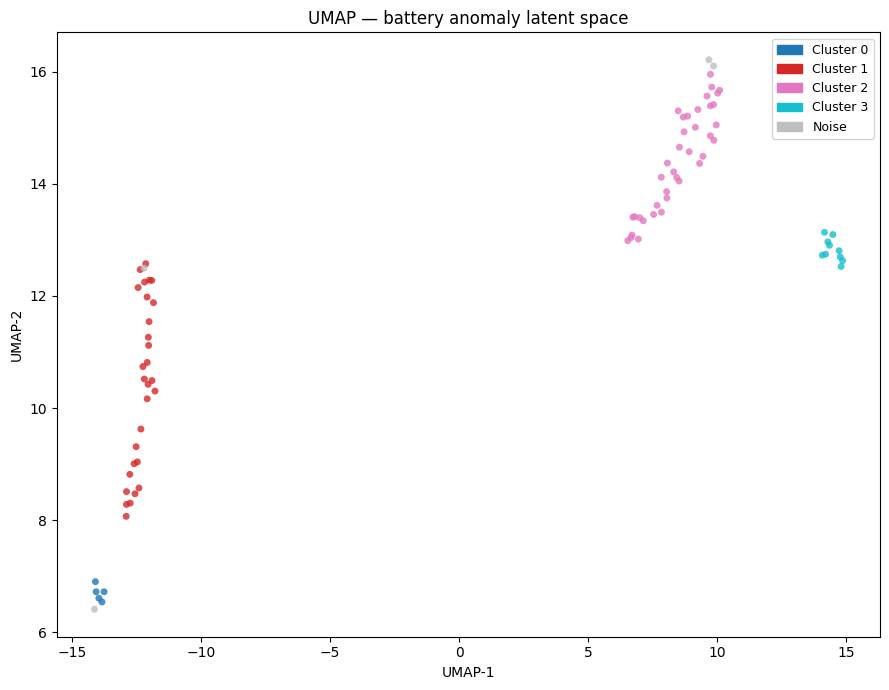

In [ ]:
# UMAP scatter
cmap   = plt.cm.get_cmap('tab10', max(n_clusters, 1))
colors = [cmap(l) if l >= 0 else (0.75,0.75,0.75,0.4) for l in cluster_labels]

plt.figure(figsize=(9, 7))
plt.scatter(embedding_2d[:,0], embedding_2d[:,1],
            c=colors, s=25, alpha=0.8, linewidths=0)
patches = [mpatches.Patch(color=cmap(i), label=f'Cluster {i}') for i in range(n_clusters)]
patches.append(mpatches.Patch(color=(0.75,0.75,0.75), label='Noise'))
plt.legend(handles=patches, fontsize=9)
plt.title('UMAP — battery anomaly latent space', fontsize=12)
plt.xlabel('UMAP-1'); plt.ylabel('UMAP-2')
plt.tight_layout(); plt.show()


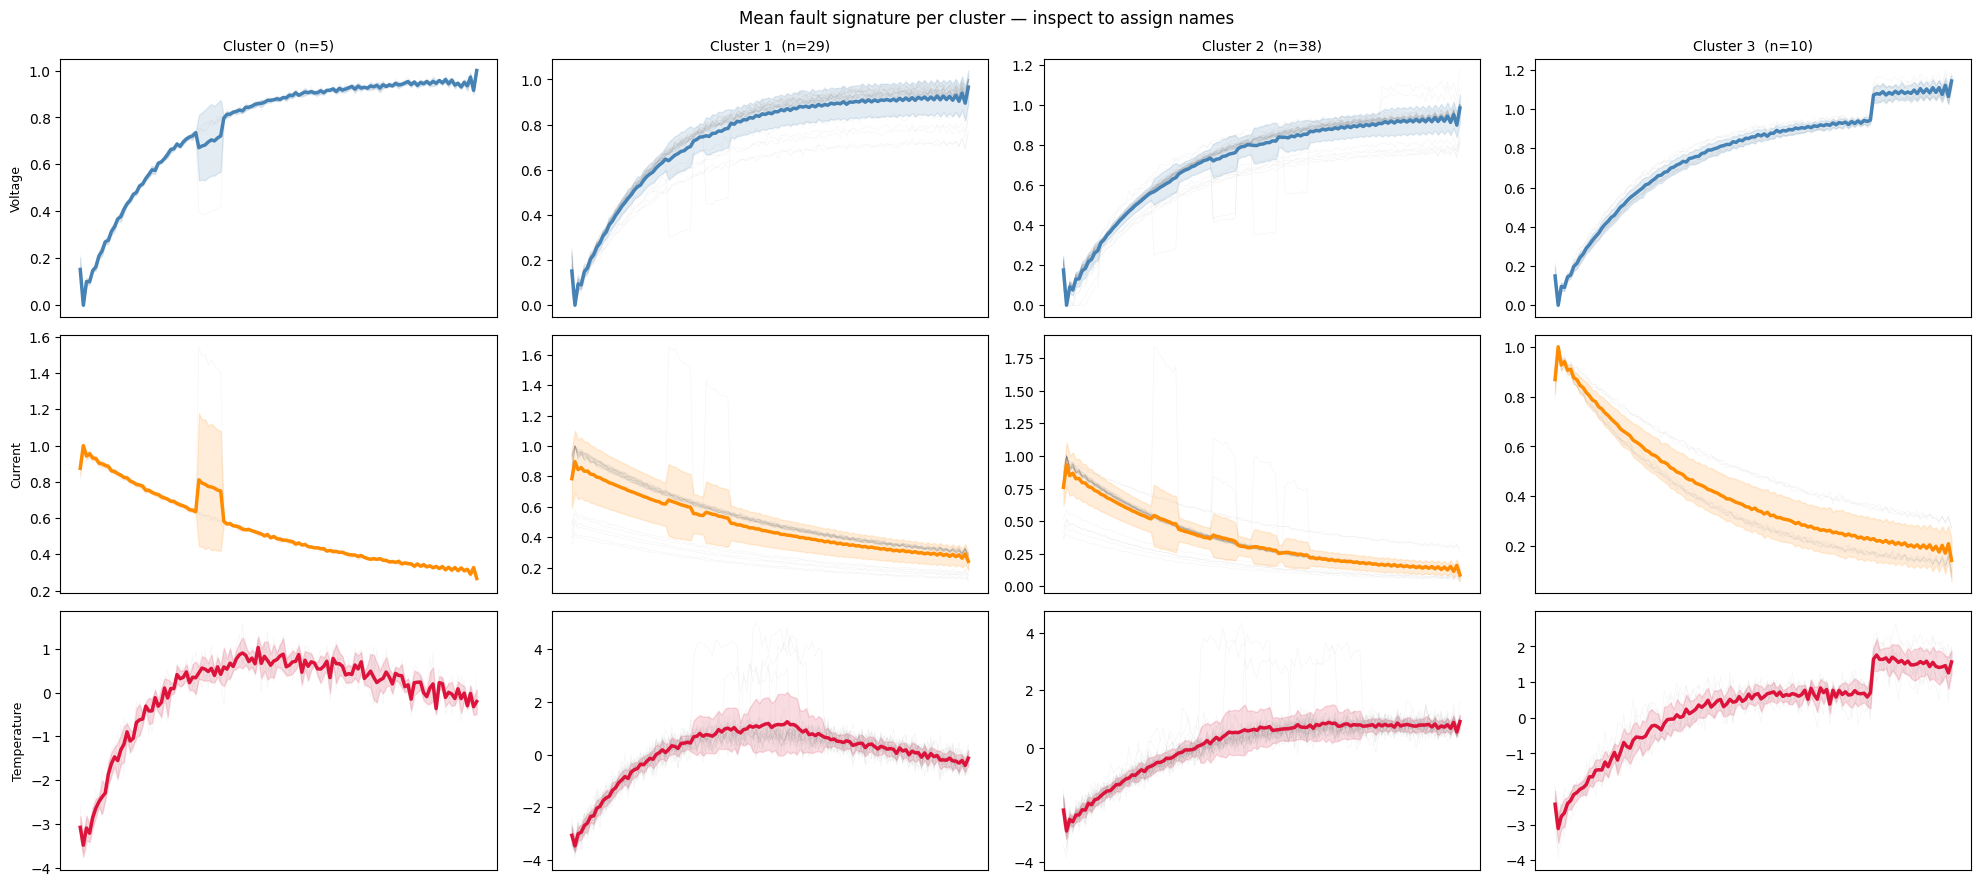

In [ ]:
# Average fault shape per cluster — show all 3 channels
n_cols = max(n_clusters, 1)
ch_names = ['Voltage', 'Current', 'Temperature']
ch_colors = ['steelblue', 'darkorange', 'crimson']

fig, axes = plt.subplots(3, n_cols, figsize=(5*n_cols, 9), squeeze=False)

for cid in range(n_clusters):
    mask = cluster_labels == cid
    cw   = anom_cycles[mask]   # (n, 3, CYCLE_LEN)
    for ch in range(3):
        ax = axes[ch, cid]
        ax.plot(cw[:, ch, :].T, color='gray', alpha=0.08, lw=0.5)
        mean = cw[:, ch, :].mean(axis=0)
        std  = cw[:, ch, :].std(axis=0)
        ax.plot(mean, color=ch_colors[ch], lw=2.5)
        ax.fill_between(range(CYCLE_LEN), mean-std, mean+std,
                        alpha=0.15, color=ch_colors[ch])
        if cid == 0: ax.set_ylabel(ch_names[ch], fontsize=9)
        if ch == 0:  ax.set_title(f'Cluster {cid}  (n={mask.sum()})', fontsize=10)
        ax.set_xticks([])

plt.suptitle('Mean fault signature per cluster — inspect to assign names', fontsize=12)
plt.tight_layout(); plt.show()


In [ ]:
# ── Update after inspecting cluster plots ─────────────────────────────────────
CLUSTER_NAMES = {
    0: 'Overcharge / voltage spike',
    1: 'Capacity fade / low current',
    2: 'Thermal fault',
    3: 'Short circuit',
    4: 'IR rise / internal resistance',
    5: 'Over-discharge',
   -1: 'Unclassified anomaly'
}
print("Update CLUSTER_NAMES above based on what you see in the plots.")


Update CLUSTER_NAMES above based on what you see in the plots.


## Phase 8 — Validation & metrics

In [ ]:
y_pred = is_anomaly_final.astype(int)

print("=== Combined detector ===")
print(classification_report(y_true, y_pred, target_names=['Normal','Fault']))

print("Per-fault-type recall:")
for name, fidx in [('Overcharge', over_idx), ('Over-discharge', under_idx),
                   ('Thermal', thermal_idx), ('Short circuit', short_idx),
                   ('Capacity fade', fade_idx), ('IR rise', ir_idx)]:
    det = len(set(fidx) & set(np.where(is_anomaly_final)[0]))
    print(f"  {name:15s}  {det/len(fidx):.2%}  ({det}/{len(fidx)})")


=== Combined detector ===
              precision    recall  f1-score   support

      Normal       0.98      0.88      0.93       229
       Fault       0.69      0.94      0.79        63

    accuracy                           0.89       292
   macro avg       0.83      0.91      0.86       292
weighted avg       0.92      0.89      0.90       292

Per-fault-type recall:
  Overcharge       100.00%  (14/14)
  Over-discharge   100.00%  (11/11)
  Thermal          100.00%  (11/11)
  Short circuit    100.00%  (8/8)
  Capacity fade    100.00%  (11/11)
  IR rise          50.00%  (4/8)


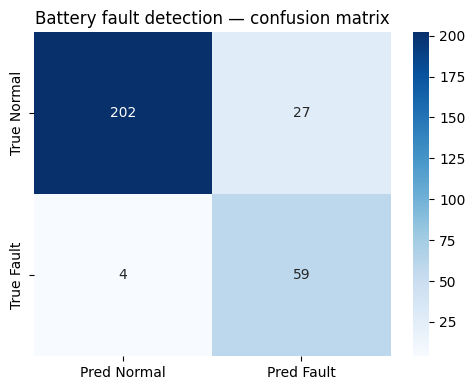

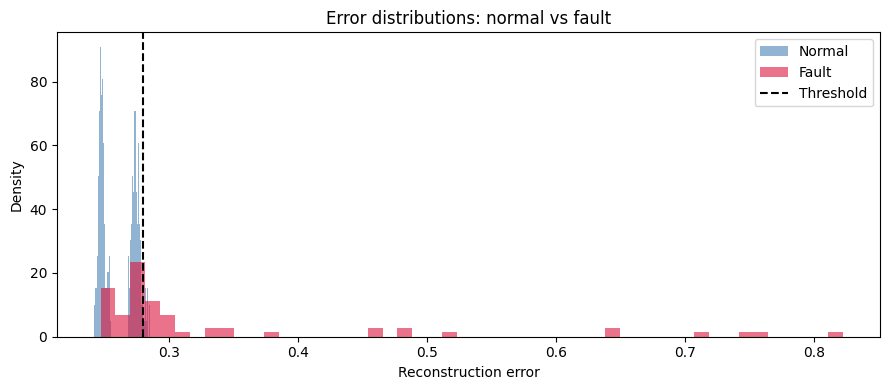

Separation ratio: 1.3x


In [ ]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Normal','Pred Fault'],
            yticklabels=['True Normal','True Fault'])
plt.title('Battery fault detection — confusion matrix')
plt.tight_layout(); plt.show()

# Error distributions
fault_err  = new_errors[y_true==1]
normal_err = new_errors[y_true==0]
plt.figure(figsize=(9,4))
plt.hist(normal_err, bins=50, alpha=0.6, label='Normal', color='steelblue', density=True)
plt.hist(fault_err,  bins=50, alpha=0.6, label='Fault',  color='crimson',   density=True)
plt.axvline(THRESHOLD, color='black', linestyle='--', label='Threshold')
plt.xlabel('Reconstruction error'); plt.ylabel('Density')
plt.title('Error distributions: normal vs fault')
plt.legend(); plt.tight_layout(); plt.show()

print(f"Separation ratio: {fault_err.mean()/normal_err.mean():.1f}x")


## Phase 9 — Combined predict function & save

In [ ]:
def predict_battery_cycle(voltage: np.ndarray,
                           current: np.ndarray,
                           temperature: np.ndarray) -> dict:
    """
    Score one battery charge cycle.

    Parameters
    ----------
    voltage, current, temperature : np.ndarray
        Raw sensor readings for one complete charge cycle.
        Any length — will be resampled internally.

    Returns
    -------
    dict:
        anomaly      (bool)
        error        (float)
        stage        (str)    which detector flagged it
        cluster_id   (int|None)
        fault_type   (str)
    """
    from scipy.signal import resample as sp_resample

    # Build cycle dict and normalize
    cyc = {'voltage': voltage, 'current': current, 'temperature': temperature}
    arr = normalize_cycle(cyc)
    if arr is None:
        return {'anomaly': False, 'error': 0.0, 'stage': None,
                'cluster_id': None, 'fault_type': 'Invalid input'}

    # Stage 1: autoencoder
    xt = torch.tensor(arr.T[None], dtype=torch.float32).to(device)  # (1, CYCLE_LEN, 3)
    model.eval()
    with torch.no_grad():
        recon, z = model(xt)
        error = ((recon - xt)**2).mean().item()
    stage1 = error > THRESHOLD

    # Stage 2: feature-based
    feats = extract_battery_features(arr)
    stage2_over  = feats['v_max']       > V_MAX_THRESH
    stage2_under = feats['v_mean']      < V_MIN_THRESH
    stage2_therm = feats['t_spike']     > T_SPIKE_THRESH
    stage2_fade  = feats['c_auc']       < C_AUC_THRESH
    stage2_ir    = feats['v_start_dip'] > IR_THRESH

    anomaly = any([stage1, stage2_over, stage2_under,
                   stage2_therm, stage2_fade, stage2_ir])

    if not anomaly:
        return {'anomaly': False, 'error': round(error,6),
                'stage': None, 'cluster_id': None, 'fault_type': 'Normal'}

    # Determine stage and fault type
    if stage2_over:    stage, fault = 'overcharge_detector',    'Overcharge'
    elif stage2_under: stage, fault = 'overdischarge_detector', 'Over-discharge'
    elif stage2_therm: stage, fault = 'thermal_detector',       'Thermal fault'
    elif stage2_fade:  stage, fault = 'capacity_detector',      'Capacity fade'
    elif stage2_ir:    stage, fault = 'ir_detector',            'Internal resistance rise'
    else:
        stage = 'autoencoder'
        z_sc  = scaler_cl.transform(z.cpu().numpy())
        labels, _ = hdbscan.approximate_predict(clusterer, z_sc)
        cid   = int(labels[0])
        fault = CLUSTER_NAMES.get(cid, f'Cluster {cid}')
        return {'anomaly': True, 'error': round(error,6),
                'stage': stage, 'cluster_id': cid, 'fault_type': fault}

    return {'anomaly': True, 'error': round(error,6),
            'stage': stage, 'cluster_id': None, 'fault_type': fault}

# ── Test ──────────────────────────────────────────────────────────────────────
def cycle_to_signals(arr):
    """Helper: convert (3, CYCLE_LEN) array back to v/c/t signals."""
    return arr[0], arr[1], arr[2]

print("Normal cycle:")
v,c,t = cycle_to_signals(X[0]); print(predict_battery_cycle(v,c,t))

print("\nOvercharge fault:")
v,c,t = cycle_to_signals(X_new[over_idx[0]]); print(predict_battery_cycle(v,c,t))

print("\nThermal fault:")
v,c,t = cycle_to_signals(X_new[thermal_idx[0]]); print(predict_battery_cycle(v,c,t))

print("\nCapacity fade:")
v,c,t = cycle_to_signals(X_new[fade_idx[0]]); print(predict_battery_cycle(v,c,t))


Normal cycle:
{'anomaly': False, 'error': 0.273913, 'stage': None, 'cluster_id': None, 'fault_type': 'Normal'}

Overcharge fault:
{'anomaly': True, 'error': 0.298858, 'stage': 'overdischarge_detector', 'cluster_id': None, 'fault_type': 'Over-discharge'}

Thermal fault:
{'anomaly': True, 'error': 0.264256, 'stage': 'thermal_detector', 'cluster_id': None, 'fault_type': 'Thermal fault'}

Capacity fade:
{'anomaly': False, 'error': 0.275056, 'stage': None, 'cluster_id': None, 'fault_type': 'Normal'}


In [ ]:
# Save everything
torch.save(model.state_dict(), 'battery_model_v1.pt')

with open('battery_artifacts_v1.pkl', 'wb') as f:
    pickle.dump({
        'threshold':       THRESHOLD,
        'v_max_thresh':    V_MAX_THRESH,
        'v_min_thresh':    V_MIN_THRESH,
        't_spike_thresh':  T_SPIKE_THRESH,
        'c_auc_thresh':    C_AUC_THRESH,
        'ir_thresh':       IR_THRESH,
        'cluster_names':   CLUSTER_NAMES,
        'cycle_len':       CYCLE_LEN,
        'scaler':          scaler_cl,
        'n_clusters':      n_clusters,
    }, f)

print("✓ Saved: battery_model_v1.pt")
print("✓ Saved: battery_artifacts_v1.pkl")


✓ Saved: battery_model_v1.pt
✓ Saved: battery_artifacts_v1.pkl


## Summary

### Detection stages
| Stage | Method | Catches |
|-------|--------|---------|
| 1 | LSTM autoencoder | Shape anomalies (short circuit, complex faults) |
| 2a | Voltage ceiling check | Overcharge |
| 2b | Voltage floor check | Over-discharge |
| 2c | Temperature spike check | Thermal fault |
| 2d | Current AUC check | Capacity fade |
| 2e | Voltage start-dip check | Internal resistance rise |

### Connecting to your solar model
```python
# Run both models every cycle / window
solar_result  = predict_window(solar_power_array)
battery_result = predict_battery_cycle(voltage, current, temperature)

if solar_result['anomaly']:
    print(f"⚡ Solar fault:   {solar_result['fault_type']}")
if battery_result['anomaly']:
    print(f"🔋 Battery fault: {battery_result['fault_type']}")
```

### Next steps
- Replace synthetic data with real NASA/CALCE cycles once downloaded
- Tune feature thresholds on real data
- Add State of Charge (SOC) estimation as an additional signal
- Add cycle-over-cycle trending to catch slow degradation early
